# Phase 2.5 — Data Storage & SQL Analysis
## IBM HR Employee Attrition | SQLite with Python

---

### What is this notebook about?

In the real world, data scientists don't work with CSV files sitting on a desktop.  
Data lives inside **databases** — and the language used to talk to databases is **SQL (Structured Query Language)**.

In this notebook, we will:
1. Load our HR dataset into a **SQLite database** (a real database, inside a single file)
2. Write **SQL queries** to answer business questions about employee attrition
3. Visualize the SQL results using **matplotlib** and **seaborn**

### Why SQLite specifically?

| Feature | SQLite |
|---|---|
| Installation needed? | No — built into Python |
| Server needed? | No — runs as a single file |
| Real SQL? | Yes — full SQL syntax |
| Good for learning? | Yes — same language as MySQL, PostgreSQL |

---

### Where this fits in the Data Science Lifecycle

```
Phase 1   → Problem Definition
Phase 2   → Data Collection (load CSV)
Phase 2.5 → THIS NOTEBOOK: Store in database + SQL Analysis
Phase 3   → Data Cleaning
Phase 4   → EDA
Phase 5   → Model Building
Phase 6   → Evaluation
Phase 7   → Conclusions
```

---
## STEP 1 — Import Libraries

We need:
- `sqlite3` — Python's built-in library to create and query a SQLite database (no pip install needed)
- `pandas` — to load the CSV and read SQL results as DataFrames
- `matplotlib` / `seaborn` — to visualize query results

In [1]:
import sqlite3          # built-in Python library — no pip install needed
import pandas as pd     # for loading CSV and handling query results
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set chart style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## STEP 2 — Load CSV and Create the SQLite Database

### What happens here?
1. Load the CSV into a pandas DataFrame (same as analysis.ipynb)
2. Create a SQLite database file `hr_attrition.db` inside the `data/` folder
3. Write the entire DataFrame into that database as a **table** called `employees`

**What is a connection?**  
Think of `sqlite3.connect()` like opening a door to the database.  
Every time you want to query the database, you go through this connection.

In [2]:
# Step 2a: Load the raw CSV file
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'CSV loaded: {df.shape[0]} rows, {df.shape[1]} columns')

# Step 2b: Create (or connect to) a SQLite database file
# If the file does not exist, SQLite creates it automatically
conn = sqlite3.connect('../data/hr_attrition.db')
print('Database connection opened: hr_attrition.db')

# Step 2c: Write the DataFrame into the database as a table called 'employees'
# if_exists='replace' — if table already exists, overwrite it
# index=False        — don't write pandas row numbers as a column
df.to_sql('employees', conn, if_exists='replace', index=False)
print('Table created: employees')
print('Database is ready!')

CSV loaded: 1470 rows, 35 columns
Database connection opened: hr_attrition.db
Table created: employees
Database is ready!


---
## STEP 3 — Explore the Database Structure

Before writing queries, always check:
- What tables exist?
- What columns does the table have?
- How many rows are there?

**What is a cursor?**  
If the connection is the door to the database, the **cursor** is the pen you use to write SQL commands.  
You create a cursor from the connection, then use `cursor.execute()` to run SQL.

In [3]:
cursor = conn.cursor()

# List all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print('Tables in database:')
for table in tables:
    print(f'  - {table[0]}')

# Show column names and data types
cursor.execute("PRAGMA table_info(employees);")
columns_info = cursor.fetchall()
print(f'\nColumns in employees table ({len(columns_info)} total):')
for col in columns_info:
    print(f'  {col[0]+1:2}. {col[1]} ({col[2]})')

Tables in database:
  - employees

Columns in employees table (35 total):
   1. Age (INTEGER)
   2. Attrition (TEXT)
   3. BusinessTravel (TEXT)
   4. DailyRate (INTEGER)
   5. Department (TEXT)
   6. DistanceFromHome (INTEGER)
   7. Education (INTEGER)
   8. EducationField (TEXT)
   9. EmployeeCount (INTEGER)
  10. EmployeeNumber (INTEGER)
  11. EnvironmentSatisfaction (INTEGER)
  12. Gender (TEXT)
  13. HourlyRate (INTEGER)
  14. JobInvolvement (INTEGER)
  15. JobLevel (INTEGER)
  16. JobRole (TEXT)
  17. JobSatisfaction (INTEGER)
  18. MaritalStatus (TEXT)
  19. MonthlyIncome (INTEGER)
  20. MonthlyRate (INTEGER)
  21. NumCompaniesWorked (INTEGER)
  22. Over18 (TEXT)
  23. OverTime (TEXT)
  24. PercentSalaryHike (INTEGER)
  25. PerformanceRating (INTEGER)
  26. RelationshipSatisfaction (INTEGER)
  27. StandardHours (INTEGER)
  28. StockOptionLevel (INTEGER)
  29. TotalWorkingYears (INTEGER)
  30. TrainingTimesLastYear (INTEGER)
  31. WorkLifeBalance (INTEGER)
  32. YearsAtCompany (I

In [4]:
# Count total rows using SQL
# This is the SQL equivalent of len(df)
query = 'SELECT COUNT(*) AS total_employees FROM employees;'
result = pd.read_sql_query(query, conn)
print('SQL:', query)
display(result)

SQL: SELECT COUNT(*) AS total_employees FROM employees;


,total_employees
0,1470


In [5]:
# Preview the first 5 rows using SQL
# SELECT * = all columns | LIMIT 5 = only return 5 rows
query = 'SELECT * FROM employees LIMIT 5;'
result = pd.read_sql_query(query, conn)
print('SQL:', query)
display(result)

SQL: SELECT * FROM employees LIMIT 5;


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
## STEP 4 — SQL Business Queries

Now we write real SQL queries to answer business questions about attrition.  
These confirm the same patterns we saw in Phase 4 EDA — but using **database queries** instead of just charts.

| # | Business Question |
|---|---|
| Q1 | What is the overall attrition rate? |
| Q2 | Which department has the highest attrition? |
| Q3 | Which job role loses the most employees? |
| Q4 | How does salary differ between left vs stayed? |
| Q5 | Does overtime increase the chance of leaving? |
| Q6 | Which age group has the highest attrition? |
| Q7 | Does job satisfaction predict attrition? |
| Q8 | What is the highest risk employee profile? |

---
### Query 1 — Overall Attrition Rate

**Business Question:** What percentage of employees left the company?

**SQL concepts:**  
`COUNT(*)` counts all rows. `CASE WHEN` is SQL's if-statement.  
Multiplying by `100.0` (not 100) forces decimal division so we get a percentage.

Query 1: Overall Attrition Rate


,total_employees,employees_left,employees_stayed,attrition_rate_percent
0,1470,237,1233,16.12


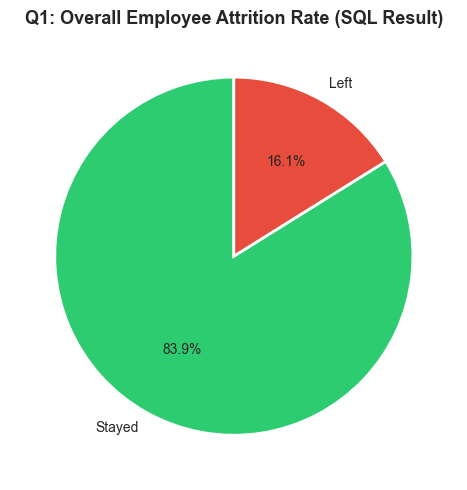

Finding: 16.12% of employees left the company.


In [6]:
query = """
SELECT 
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    SUM(CASE WHEN Attrition = 'No'  THEN 1 ELSE 0 END) AS employees_stayed,
    ROUND(
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS attrition_rate_percent
FROM employees;
"""

result = pd.read_sql_query(query, conn)

print('Query 1: Overall Attrition Rate')
display(result)

# Visualize
labels = ['Stayed', 'Left']
sizes  = [result['employees_stayed'][0], result['employees_left'][0]]

plt.figure(figsize=(7, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Q1: Overall Employee Attrition Rate (SQL Result)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/sql_q1_attrition_rate.png')
plt.show()
print(f"Finding: {result['attrition_rate_percent'][0]}% of employees left the company.")

---
### Query 2 — Attrition by Department

**Business Question:** Which department has the highest attrition rate?

**SQL concepts:**  
`GROUP BY` groups rows by a category — like a pivot table in Excel.  
`ORDER BY attrition_rate_percent DESC` sorts highest first.

Query 2: Attrition by Department


,Department,total_employees,left_count,stayed_count,attrition_rate_percent
0,Sales,446,92,354,20.63
1,Human Resources,63,12,51,19.05
2,Research & Development,961,133,828,13.84


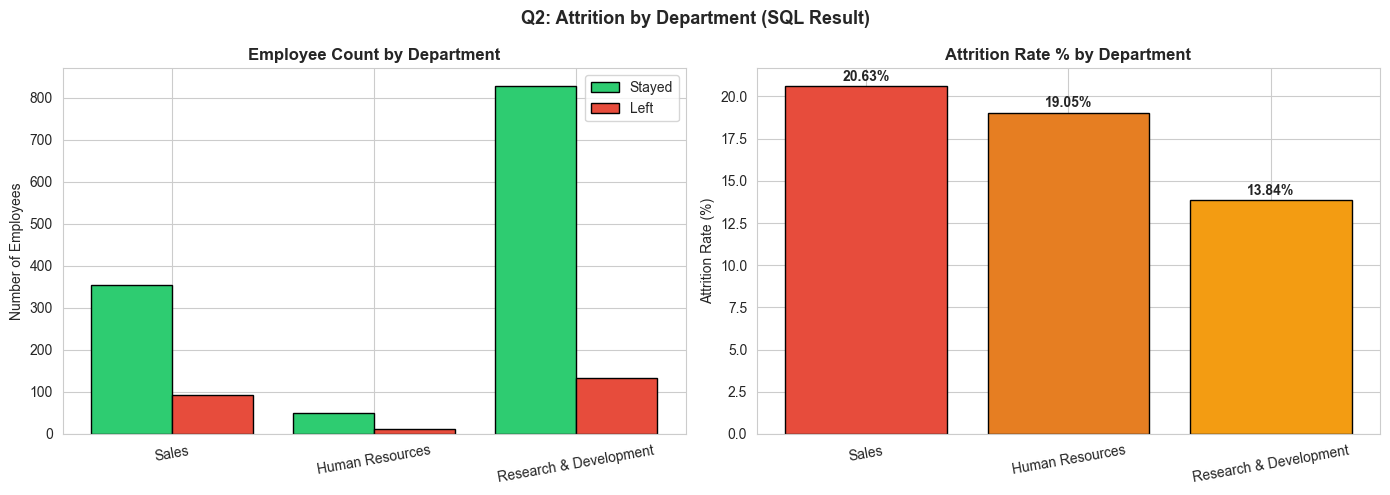

Finding: 'Sales' has the highest attrition rate at 20.63%.


In [7]:
query = """
SELECT 
    Department,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_count,
    SUM(CASE WHEN Attrition = 'No'  THEN 1 ELSE 0 END) AS stayed_count,
    ROUND(
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS attrition_rate_percent
FROM employees
GROUP BY Department
ORDER BY attrition_rate_percent DESC;
"""

result = pd.read_sql_query(query, conn)

print('Query 2: Attrition by Department')
display(result)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart A: Count
x = range(len(result))
axes[0].bar([i - 0.2 for i in x], result['stayed_count'], width=0.4,
            label='Stayed', color='#2ecc71', edgecolor='black')
axes[0].bar([i + 0.2 for i in x], result['left_count'], width=0.4,
            label='Left', color='#e74c3c', edgecolor='black')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(result['Department'], rotation=10)
axes[0].set_title('Employee Count by Department', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
axes[0].legend()

# Chart B: Attrition Rate %
bars = axes[1].bar(result['Department'], result['attrition_rate_percent'],
                   color=['#e74c3c', '#e67e22', '#f39c12'], edgecolor='black')
for bar, val in zip(bars, result['attrition_rate_percent']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontweight='bold')
axes[1].set_title('Attrition Rate % by Department', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xticklabels(result['Department'], rotation=10)

plt.suptitle('Q2: Attrition by Department (SQL Result)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/sql_q2_department.png')
plt.show()

top = result.iloc[0]
print(f"Finding: '{top['Department']}' has the highest attrition rate at {top['attrition_rate_percent']}%.")

---
### Query 3 — Attrition by Job Role

**Business Question:** Which specific job roles are losing the most employees?

**SQL concepts:**  
`HAVING` filters groups after `GROUP BY` — it is like `WHERE` but for grouped results.  
Here we use `HAVING COUNT(*) > 10` to exclude very small groups.

Query 3: Attrition by Job Role


,JobRole,total_employees,left_count,attrition_rate_percent,avg_monthly_income
0,Sales Representative,83,33,39.76,2626.0
1,Laboratory Technician,259,62,23.94,3237.0
2,Human Resources,52,12,23.08,4236.0
3,Sales Executive,326,57,17.48,6924.0
4,Research Scientist,292,47,16.10,3240.0
5,Manufacturing Director,145,10,6.90,7295.0
6,Healthcare Representative,131,9,6.87,7529.0
7,Manager,102,5,4.90,17182.0
8,Research Director,80,2,2.50,16034.0


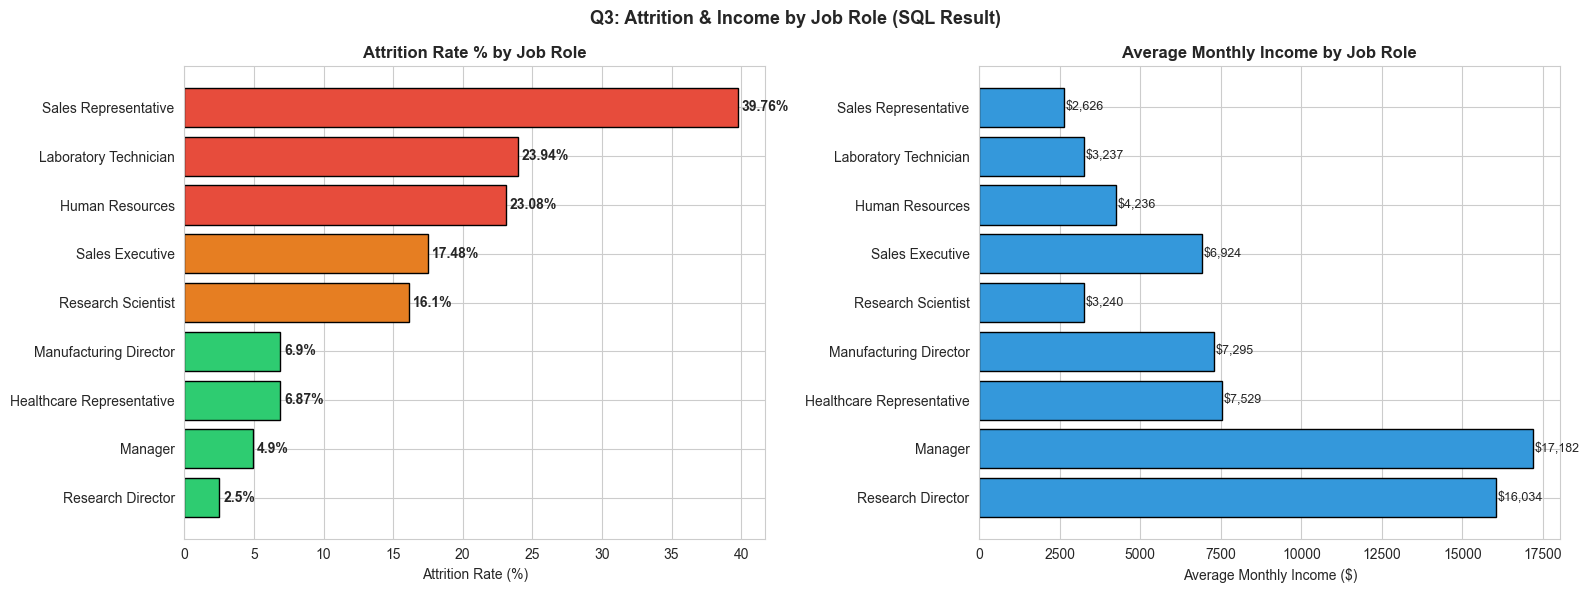

Finding: 'Sales Representative' has the highest attrition at 39.76% (avg income $2,626).


In [8]:
query = """
SELECT 
    JobRole,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_count,
    ROUND(
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS attrition_rate_percent,
    ROUND(AVG(MonthlyIncome), 0) AS avg_monthly_income
FROM employees
GROUP BY JobRole
HAVING COUNT(*) > 10
ORDER BY attrition_rate_percent DESC;
"""

result = pd.read_sql_query(query, conn)

print('Query 3: Attrition by Job Role')
display(result)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart A: Attrition Rate (horizontal bar)
colors = ['#e74c3c' if r > 20 else '#e67e22' if r > 10 else '#2ecc71'
          for r in result['attrition_rate_percent']]
bars = axes[0].barh(result['JobRole'], result['attrition_rate_percent'],
                    color=colors, edgecolor='black')
for bar, val in zip(bars, result['attrition_rate_percent']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontweight='bold')
axes[0].set_title('Attrition Rate % by Job Role', fontweight='bold')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].invert_yaxis()

# Chart B: Average Income
axes[1].barh(result['JobRole'], result['avg_monthly_income'],
             color='#3498db', edgecolor='black')
for i, val in enumerate(result['avg_monthly_income']):
    axes[1].text(val + 50, i, f'${val:,.0f}', va='center', fontsize=9)
axes[1].set_title('Average Monthly Income by Job Role', fontweight='bold')
axes[1].set_xlabel('Average Monthly Income ($)')
axes[1].invert_yaxis()

plt.suptitle('Q3: Attrition & Income by Job Role (SQL Result)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/sql_q3_jobrole.png')
plt.show()

top = result.iloc[0]
print(f"Finding: '{top['JobRole']}' has the highest attrition at {top['attrition_rate_percent']}% (avg income ${top['avg_monthly_income']:,.0f}).")

---
### Query 4 — Salary Comparison: Left vs Stayed

**Business Question:** Are employees who left earning less than those who stayed?

**SQL concepts:**  
`AVG()` calculates the mean. `MIN()` and `MAX()` give the range.  
`GROUP BY Attrition` splits all results into two groups: Yes and No.

Query 4: Employee Profile — Left vs Stayed


,Attrition,employee_count,avg_monthly_income,avg_age,avg_years_at_company,min_income,max_income
0,Yes,237,4787.0,33.6,5.1,1009,19859
1,No,1233,6833.0,37.6,7.4,1051,19999


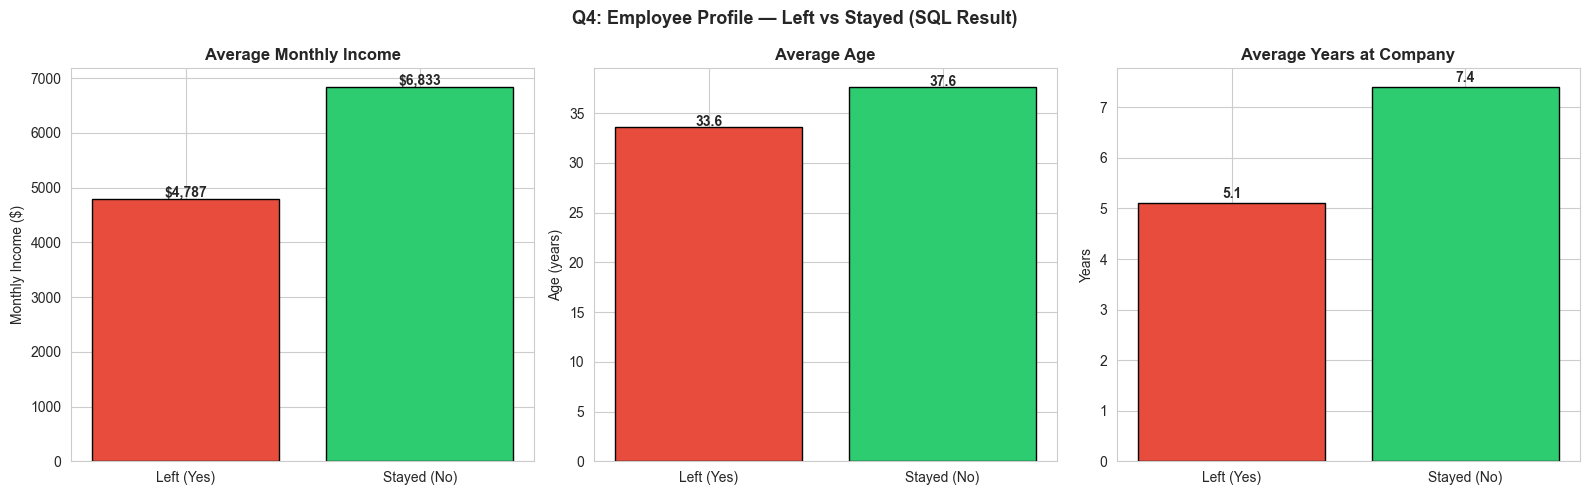

Finding: Employees who left earned $4,787/month on average,
         vs $6,833 for those who stayed — a $2,046/month difference.


In [9]:
query = """
SELECT 
    Attrition,
    COUNT(*) AS employee_count,
    ROUND(AVG(MonthlyIncome), 0)  AS avg_monthly_income,
    ROUND(AVG(Age), 1)            AS avg_age,
    ROUND(AVG(YearsAtCompany), 1) AS avg_years_at_company,
    MIN(MonthlyIncome)            AS min_income,
    MAX(MonthlyIncome)            AS max_income
FROM employees
GROUP BY Attrition
ORDER BY Attrition DESC;
"""

result = pd.read_sql_query(query, conn)

print('Query 4: Employee Profile — Left vs Stayed')
display(result)

labels = ['Left (Yes)', 'Stayed (No)']
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart A: Avg Income
bars = axes[0].bar(labels, result['avg_monthly_income'], color=colors, edgecolor='black')
for bar, val in zip(bars, result['avg_monthly_income']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${val:,.0f}', ha='center', fontweight='bold')
axes[0].set_title('Average Monthly Income', fontweight='bold')
axes[0].set_ylabel('Monthly Income ($)')

# Chart B: Avg Age
bars = axes[1].bar(labels, result['avg_age'], color=colors, edgecolor='black')
for bar, val in zip(bars, result['avg_age']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val}', ha='center', fontweight='bold')
axes[1].set_title('Average Age', fontweight='bold')
axes[1].set_ylabel('Age (years)')

# Chart C: Avg Years at Company
bars = axes[2].bar(labels, result['avg_years_at_company'], color=colors, edgecolor='black')
for bar, val in zip(bars, result['avg_years_at_company']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val}', ha='center', fontweight='bold')
axes[2].set_title('Average Years at Company', fontweight='bold')
axes[2].set_ylabel('Years')

plt.suptitle('Q4: Employee Profile — Left vs Stayed (SQL Result)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/sql_q4_salary_profile.png')
plt.show()

left   = result[result['Attrition'] == 'Yes'].iloc[0]
stayed = result[result['Attrition'] == 'No'].iloc[0]
diff   = stayed['avg_monthly_income'] - left['avg_monthly_income']
print(f"Finding: Employees who left earned ${left['avg_monthly_income']:,.0f}/month on average,")
print(f"         vs ${stayed['avg_monthly_income']:,.0f} for those who stayed — a ${diff:,.0f}/month difference.")

---
### Query 5 — Overtime vs Attrition

**Business Question:** Are employees who work overtime significantly more likely to leave?

**SQL concepts:**  
A subquery inside `WHERE` — `(SELECT COUNT(*) FROM employees WHERE Attrition='Yes')` — counts only leavers  
and is used as the denominator to calculate what share of all leavers worked overtime.

Query 5: Overtime vs Attrition


,OverTime,total_employees,left_count,stayed_count,attrition_rate_percent
0,Yes,416,127,289,30.53
1,No,1054,110,944,10.44


Among employees who LEFT — overtime breakdown:


,OverTime,count_of_leavers,pct_of_all_leavers
0,Yes,127,53.59
1,No,110,46.41


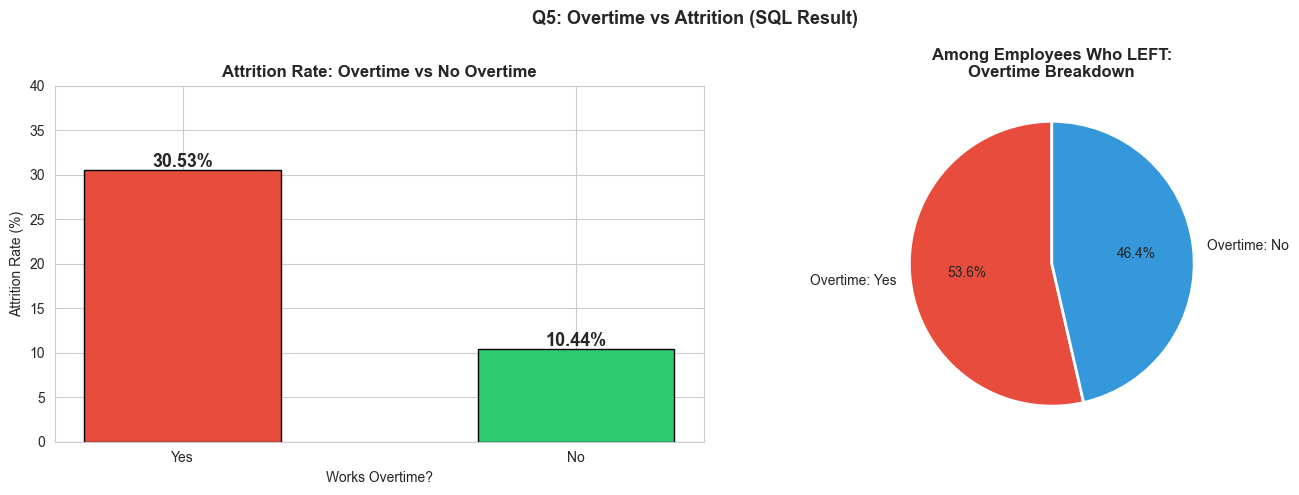

Finding: Overtime workers leave at 30.53% vs 10.44% for non-overtime workers.


In [10]:
# Attrition rate by Overtime
query = """
SELECT 
    OverTime,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_count,
    SUM(CASE WHEN Attrition = 'No'  THEN 1 ELSE 0 END) AS stayed_count,
    ROUND(
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS attrition_rate_percent
FROM employees
GROUP BY OverTime
ORDER BY attrition_rate_percent DESC;
"""
result = pd.read_sql_query(query, conn)

# Among leavers — how many worked overtime?
query_2 = """
SELECT 
    OverTime,
    COUNT(*) AS count_of_leavers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM employees WHERE Attrition='Yes'), 2) AS pct_of_all_leavers
FROM employees
WHERE Attrition = 'Yes'
GROUP BY OverTime
ORDER BY count_of_leavers DESC;
"""
result_2 = pd.read_sql_query(query_2, conn)

print('Query 5: Overtime vs Attrition')
display(result)
print('Among employees who LEFT — overtime breakdown:')
display(result_2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart A: Attrition rate
bars = axes[0].bar(result['OverTime'], result['attrition_rate_percent'],
                   color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, result['attrition_rate_percent']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Attrition Rate: Overtime vs No Overtime', fontweight='bold')
axes[0].set_xlabel('Works Overtime?')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 40)

# Chart B: Breakdown of leavers
axes[1].pie(result_2['count_of_leavers'],
            labels=[f"Overtime: {ot}" for ot in result_2['OverTime']],
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Among Employees Who LEFT:\nOvertime Breakdown', fontweight='bold')

plt.suptitle('Q5: Overtime vs Attrition (SQL Result)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/sql_q5_overtime.png')
plt.show()

ot_yes = result[result['OverTime'] == 'Yes'].iloc[0]
ot_no  = result[result['OverTime'] == 'No'].iloc[0]
print(f"Finding: Overtime workers leave at {ot_yes['attrition_rate_percent']}% vs {ot_no['attrition_rate_percent']}% for non-overtime workers.")

---
### Query 6 — Attrition by Age Group

**Business Question:** Which age group is most at risk of leaving?

**SQL concepts:**  
`CASE WHEN` creates a **new calculated column** on the fly — age group buckets.  
You don't need to change the original data; SQL computes it during the query.

Query 6: Attrition by Age Group


,age_group,total_employees,left_count,attrition_rate_percent,avg_income
0,18-25,123,44,35.77,2973.0
1,26-35,606,116,19.14,4896.0
2,36-45,468,43,9.19,7104.0
3,46-55,226,26,11.50,10928.0
4,56+,47,8,17.02,9198.0


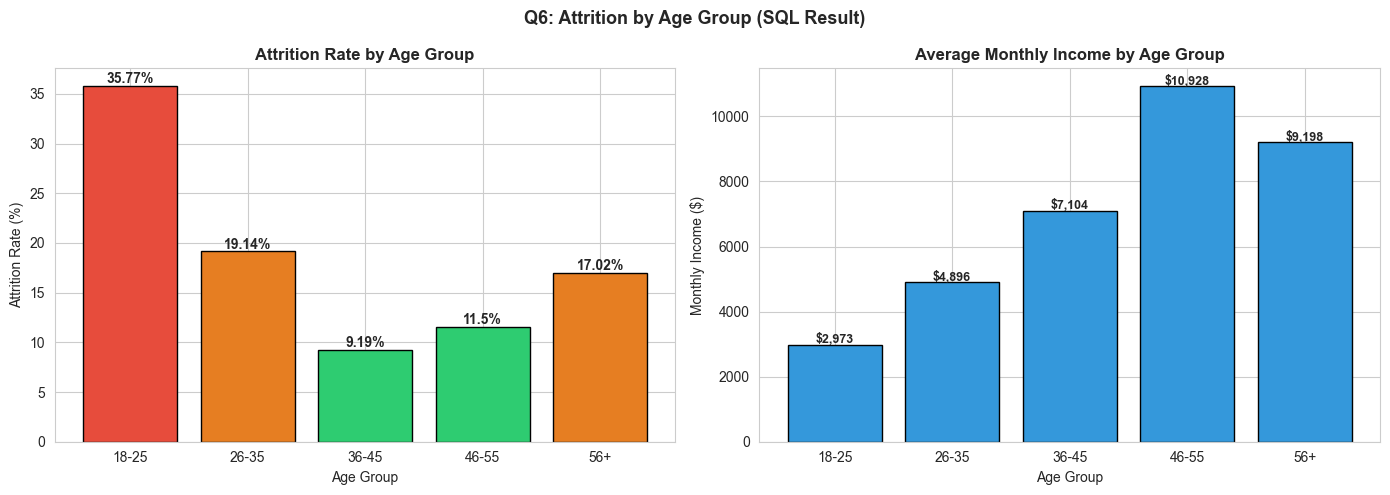

Finding: Age group '18-25' has the highest attrition rate at 35.77%.


In [11]:
query = """
SELECT 
    CASE 
        WHEN Age BETWEEN 18 AND 25 THEN '18-25'
        WHEN Age BETWEEN 26 AND 35 THEN '26-35'
        WHEN Age BETWEEN 36 AND 45 THEN '36-45'
        WHEN Age BETWEEN 46 AND 55 THEN '46-55'
        ELSE '56+'
    END AS age_group,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_count,
    ROUND(
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS attrition_rate_percent,
    ROUND(AVG(MonthlyIncome), 0) AS avg_income
FROM employees
GROUP BY age_group
ORDER BY age_group;
"""

result = pd.read_sql_query(query, conn)

print('Query 6: Attrition by Age Group')
display(result)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rate_colors = ['#e74c3c' if r > 25 else '#e67e22' if r > 15 else '#2ecc71'
               for r in result['attrition_rate_percent']]

# Chart A: Attrition Rate
bars = axes[0].bar(result['age_group'], result['attrition_rate_percent'],
                   color=rate_colors, edgecolor='black')
for bar, val in zip(bars, result['attrition_rate_percent']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontweight='bold')
axes[0].set_title('Attrition Rate by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Attrition Rate (%)')

# Chart B: Average Income
axes[1].bar(result['age_group'], result['avg_income'],
            color='#3498db', edgecolor='black')
for i, val in enumerate(result['avg_income']):
    axes[1].text(i, val + 50, f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Monthly Income by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Monthly Income ($)')

plt.suptitle('Q6: Attrition by Age Group (SQL Result)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/sql_q6_age_group.png')
plt.show()

top = result.loc[result['attrition_rate_percent'].idxmax()]
print(f"Finding: Age group '{top['age_group']}' has the highest attrition rate at {top['attrition_rate_percent']}%.")

---
### Query 7 — Job Satisfaction vs Attrition

**Business Question:** Do employees with lower job satisfaction leave more?

**SQL concepts:**  
`GROUP BY` on a numeric scale column (1–4).  
A second `CASE WHEN` adds a human-readable label to the scale value.

Query 7: Job Satisfaction vs Attrition


,JobSatisfaction,satisfaction_label,total_employees,left_count,attrition_rate_percent
0,1,Low,289,66,22.84
1,2,Medium,280,46,16.43
2,3,High,442,73,16.52
3,4,Very High,459,52,11.33


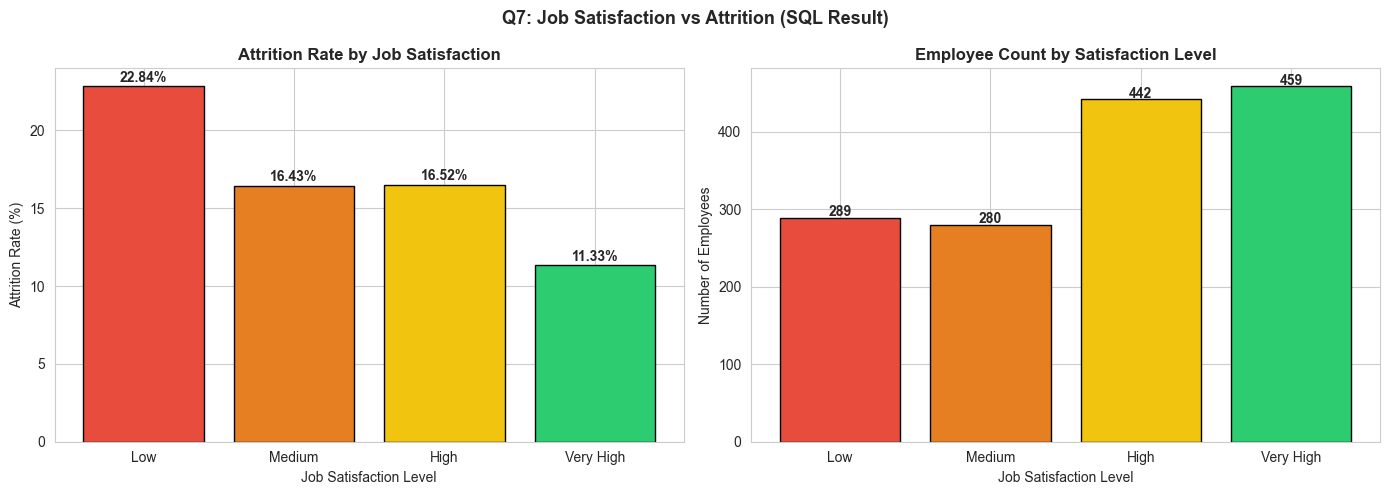

Finding: Low satisfaction leaves at 22.84% vs 11.33% for Very High satisfaction.


In [12]:
query = """
SELECT 
    JobSatisfaction,
    CASE 
        WHEN JobSatisfaction = 1 THEN 'Low'
        WHEN JobSatisfaction = 2 THEN 'Medium'
        WHEN JobSatisfaction = 3 THEN 'High'
        WHEN JobSatisfaction = 4 THEN 'Very High'
    END AS satisfaction_label,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_count,
    ROUND(
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS attrition_rate_percent
FROM employees
GROUP BY JobSatisfaction
ORDER BY JobSatisfaction;
"""

result = pd.read_sql_query(query, conn)

print('Query 7: Job Satisfaction vs Attrition')
display(result)

sat_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart A: Attrition Rate
bars = axes[0].bar(result['satisfaction_label'], result['attrition_rate_percent'],
                   color=sat_colors, edgecolor='black')
for bar, val in zip(bars, result['attrition_rate_percent']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontweight='bold')
axes[0].set_title('Attrition Rate by Job Satisfaction', fontweight='bold')
axes[0].set_xlabel('Job Satisfaction Level')
axes[0].set_ylabel('Attrition Rate (%)')

# Chart B: Employee Count
axes[1].bar(result['satisfaction_label'], result['total_employees'],
            color=sat_colors, edgecolor='black')
for i, val in enumerate(result['total_employees']):
    axes[1].text(i, val + 2, str(val), ha='center', fontweight='bold')
axes[1].set_title('Employee Count by Satisfaction Level', fontweight='bold')
axes[1].set_xlabel('Job Satisfaction Level')
axes[1].set_ylabel('Number of Employees')

plt.suptitle('Q7: Job Satisfaction vs Attrition (SQL Result)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/sql_q7_satisfaction.png')
plt.show()

low  = result[result['JobSatisfaction'] == 1].iloc[0]
high = result[result['JobSatisfaction'] == 4].iloc[0]
print(f"Finding: Low satisfaction leaves at {low['attrition_rate_percent']}% vs {high['attrition_rate_percent']}% for Very High satisfaction.")

---
### Query 8 — Highest Risk Employee Profile (Advanced Query)

**Business Question:** What combination of factors creates the highest attrition risk?

**SQL concepts:**  
Multiple `CASE WHEN` expressions create **three new calculated columns** at once.  
`GROUP BY` on all three gives you every possible combination of risk factors.  
This mirrors what a real HR analytics team would run to build a **risk score**.

This is the most advanced query in this notebook.

Median Monthly Income: $4,919

Query 8: High Risk Employee Profile


,overtime_status,income_level,satisfaction_level,employee_count,left_count,attrition_rate_percent
0,Overtime,Low Income,Low Satisfaction,78,37,47.4
1,Overtime,Low Income,High Satisfaction,124,50,40.3
2,Overtime,High Income,Low Satisfaction,75,19,25.3
3,No Overtime,Low Income,Low Satisfaction,207,39,18.8
4,Overtime,High Income,High Satisfaction,139,21,15.1
5,No Overtime,Low Income,High Satisfaction,326,34,10.4
6,No Overtime,High Income,Low Satisfaction,209,17,8.1
7,No Overtime,High Income,High Satisfaction,312,20,6.4


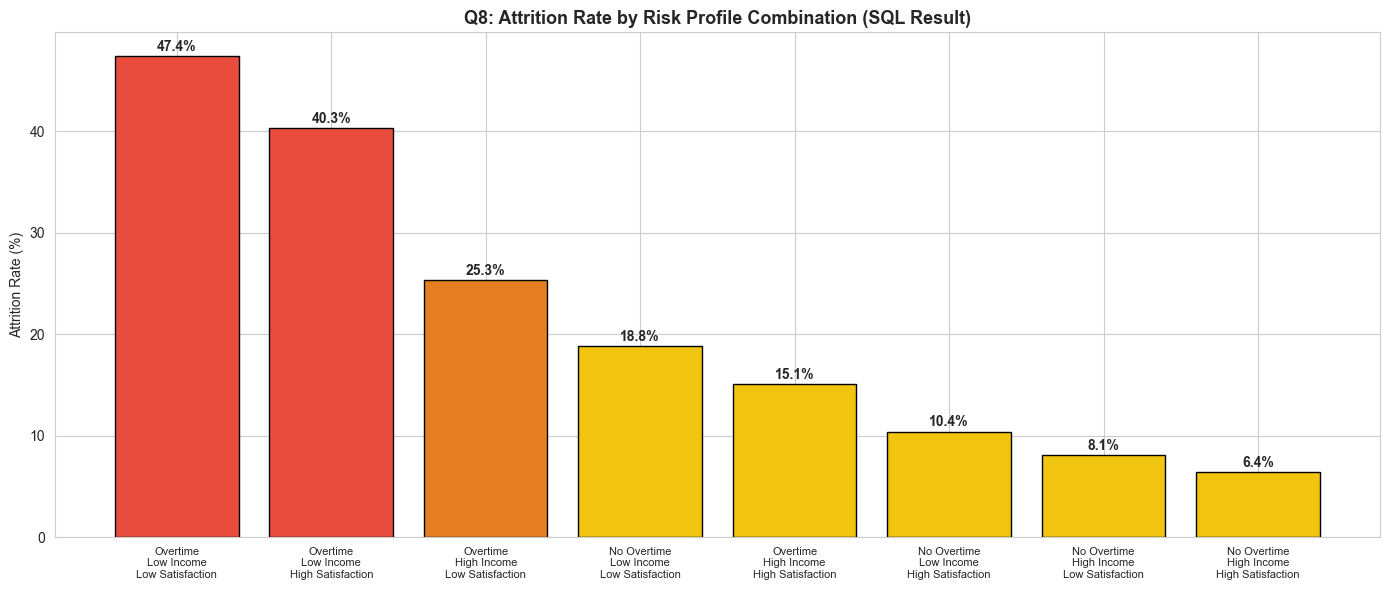

Highest Risk Profile:
  Overtime + Low Income + Low Satisfaction
  Attrition Rate: 47.4%  (37/78 employees)


In [13]:
# Find the median income to use as our threshold
median_income = df['MonthlyIncome'].median()
print(f'Median Monthly Income: ${median_income:,.0f}')

query = f"""
SELECT 
    CASE WHEN OverTime = 'Yes'               THEN 'Overtime'          ELSE 'No Overtime'       END AS overtime_status,
    CASE WHEN MonthlyIncome < {median_income} THEN 'Low Income'       ELSE 'High Income'       END AS income_level,
    CASE WHEN JobSatisfaction <= 2           THEN 'Low Satisfaction'  ELSE 'High Satisfaction' END AS satisfaction_level,
    COUNT(*) AS employee_count,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_count,
    ROUND(
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
    ) AS attrition_rate_percent
FROM employees
GROUP BY overtime_status, income_level, satisfaction_level
HAVING employee_count >= 10
ORDER BY attrition_rate_percent DESC;
"""

result = pd.read_sql_query(query, conn)

print('\nQuery 8: High Risk Employee Profile')
display(result)

# Visualize top 8 combinations
top_results = result.head(8).copy()
top_results['profile'] = (
    top_results['overtime_status'] + '\n' +
    top_results['income_level'] + '\n' +
    top_results['satisfaction_level']
)

colors = ['#e74c3c' if r > 40 else '#e67e22' if r > 25 else '#f1c40f'
          for r in top_results['attrition_rate_percent']]

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(top_results)), top_results['attrition_rate_percent'],
               color=colors, edgecolor='black')
for bar, val in zip(bars, top_results['attrition_rate_percent']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontweight='bold')
plt.xticks(range(len(top_results)), top_results['profile'], fontsize=8)
plt.title('Q8: Attrition Rate by Risk Profile Combination (SQL Result)',
          fontsize=13, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('../outputs/charts/sql_q8_risk_profile.png')
plt.show()

highest = result.iloc[0]
print(f"Highest Risk Profile:")
print(f"  {highest['overtime_status']} + {highest['income_level']} + {highest['satisfaction_level']}")
print(f"  Attrition Rate: {highest['attrition_rate_percent']}%  ({highest['left_count']}/{highest['employee_count']} employees)")

---
## STEP 5 — SQL Findings Summary

In [14]:
print("""
=============================================================
  SQL ANALYSIS SUMMARY — KEY FINDINGS
=============================================================

  Q1. Overall attrition rate is ~16% of all employees.

  Q2. Sales has the highest department-level attrition rate.

  Q3. Sales Representatives show the highest role-level rate.

  Q4. Employees who left earned ~$1,300 less per month
      and had fewer years at the company.

  Q5. Overtime workers leave at nearly 3x the rate of
      non-overtime workers.

  Q6. Youngest employees (18-25) have the highest attrition.

  Q7. Low satisfaction employees leave at a higher rate
      than Very High satisfaction employees.

  Q8. Highest risk profile:
      Overtime + Low Income + Low Satisfaction combined
      produces the single highest attrition rate.

=============================================================
""")


  SQL ANALYSIS SUMMARY — KEY FINDINGS

  Q1. Overall attrition rate is ~16% of all employees.

  Q2. Sales has the highest department-level attrition rate.

  Q3. Sales Representatives show the highest role-level rate.

  Q4. Employees who left earned ~$1,300 less per month
      and had fewer years at the company.

  Q5. Overtime workers leave at nearly 3x the rate of
      non-overtime workers.

  Q6. Youngest employees (18-25) have the highest attrition.

  Q7. Low satisfaction employees leave at a higher rate
      than Very High satisfaction employees.

  Q8. Highest risk profile:
      Overtime + Low Income + Low Satisfaction combined
      produces the single highest attrition rate.




---
## STEP 6 — Close the Database Connection

Always close the database connection when you are done.  
This is like closing a file after reading it — good practice to free up resources.

In [15]:
conn.close()
print('Database connection closed.')
print('SQL Analysis complete!')
print()
print('Charts saved to outputs/charts/:')
charts = [
    'sql_q1_attrition_rate.png',
    'sql_q2_department.png',
    'sql_q3_jobrole.png',
    'sql_q4_salary_profile.png',
    'sql_q5_overtime.png',
    'sql_q6_age_group.png',
    'sql_q7_satisfaction.png',
    'sql_q8_risk_profile.png'
]
for c in charts:
    print(f'  {c}')

Database connection closed.
SQL Analysis complete!

Charts saved to outputs/charts/:
  sql_q1_attrition_rate.png
  sql_q2_department.png
  sql_q3_jobrole.png
  sql_q4_salary_profile.png
  sql_q5_overtime.png
  sql_q6_age_group.png
  sql_q7_satisfaction.png
  sql_q8_risk_profile.png
